In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt  
import seaborn as sns  
import random 

import torch 
from supervised_training import train_supervised

In [2]:
budgets = [10,20,40,80]
seeds = [0,1,2,3,4]

In [4]:
# Unsupervised
typiclust_unsup = {
    B: np.load(f"../TPCRP_Algorithm/unsupervised_budget_results/typiclust_B{B}.npy")
    for B in budgets
}

# Self-supervised (TPCRP)
typiclust_ssl = {
    B: np.load(f"../TPCRP_Algorithm/unmodified_budget_results/typiclust_B{B}.npy")
    for B in budgets
}

# Fully supervised
typiclust_sup = {
    B: np.load(f"../TPCRP_Algorithm/supervised_budget_results/typiclust_B{B}.npy")
    for B in budgets
}


In [5]:
N = 50000 # CIFAR-10 SIZE
def generate_random_indices(seed, B):
    rng = np.random.RandomState(seed)
    return rng.choice(N, size=B, replace=False)


In [6]:
results = []

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    for B in budgets:

        # --- Unsupervised TypiClust ---
        idx = typiclust_unsup[B]
        acc, loss, runtime = train_supervised(idx, epochs=50)
        results.append({"method": "Unsupervised", "budget": B, "seed": seed,
                        "accuracy": acc, "runtime": runtime})

        # --- Self-supervised TypiClust ---
        idx = typiclust_ssl[B]
        acc, loss, runtime = train_supervised(idx, epochs=50)
        results.append({"method": "Self-supervised", "budget": B, "seed": seed,
                        "accuracy": acc, "runtime": runtime})

        # --- Fully supervised TypiClust ---
        idx = typiclust_sup[B]
        acc, loss, runtime = train_supervised(idx, epochs=50)
        results.append({"method": "Supervised", "budget": B, "seed": seed,
                        "accuracy": acc, "runtime": runtime})

        # --- Random baseline ---
        idx = generate_random_indices(seed, B)
        acc, loss, runtime = train_supervised(idx, epochs=50)
        results.append({"method": "Random", "budget": B, "seed": seed,
                        "accuracy": acc, "runtime": runtime})

df = pd.DataFrame(results)
df.to_csv("typiclust_framework_comparison.csv", index=False)
df


/home/ariag/5CCSAMLF/large_meshupar/env/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Epoch 1/50 ::: Loss 2.3922
Epoch 2/50 ::: Loss 3.3699
Epoch 3/50 ::: Loss 8.2907
Epoch 4/50 ::: Loss 3.0341
Epoch 5/50 ::: Loss 2.4377
Epoch 6/50 ::: Loss 2.1006
Epoch 7/50 ::: Loss 2.2582
Epoch 8/50 ::: Loss 2.9546
Epoch 9/50 ::: Loss 1.9550
Epoch 10/50 ::: Loss 1.7211
Epoch 11/50 ::: Loss 1.6182
Epoch 12/50 ::: Loss 1.0315
Epoch 13/50 ::: Loss 1.3230
Epoch 14/50 ::: Loss 1.1476
Epoch 15/50 ::: Loss 1.3282
Epoch 16/50 ::: Loss 1.2227
Epoch 17/50 ::: Loss 1.6644
Epoch 18/50 ::: Loss 1.2620
Epoch 19/50 ::: Loss 0.9747
Epoch 20/50 ::: Loss 1.3926
Epoch 21/50 ::: Loss 0.5729
Epoch 22/50 ::: Loss 1.0924
Epoch 23/50 ::: Loss 0.4134
Epoch 24/50 ::: Loss 0.6235
Epoch 25/50 ::: Loss 0.7228
Epoch 26/50 ::: Loss 0.3080
Epoch 27/50 ::: Loss 0.2577
Epoch 28/50 ::: Loss 0.4553
Epoch 29/50 ::: Loss 0.1744
Epoch 30/50 ::: Loss 0.1732
Epoch 31/50 ::: Loss 0.2425
Epoch 32/50 ::: Loss 0.2347
Epoch 33/50 ::: Loss 0.1404
Epoch 34/50 ::: Loss 0.1423
Epoch 35/50 ::: Loss 0.1484
Epoch 36/50 ::: Loss 0.0854
E

,method,budget,seed,accuracy,runtime
0,Unsupervised,10,0,0.1463,9.598393
1,Self-supervised,10,0,0.1153,8.114319
2,Supervised,10,0,0.1554,9.880149
3,Random,10,0,0.1368,10.029588
4,Unsupervised,20,0,0.1563,8.527282
...,...,...,...,...,...
75,Random,40,4,0.1886,11.711759
76,Unsupervised,80,4,0.2890,11.460744
77,Self-supervised,80,4,0.2533,12.894618
78,Supervised,80,4,0.2414,10.257515


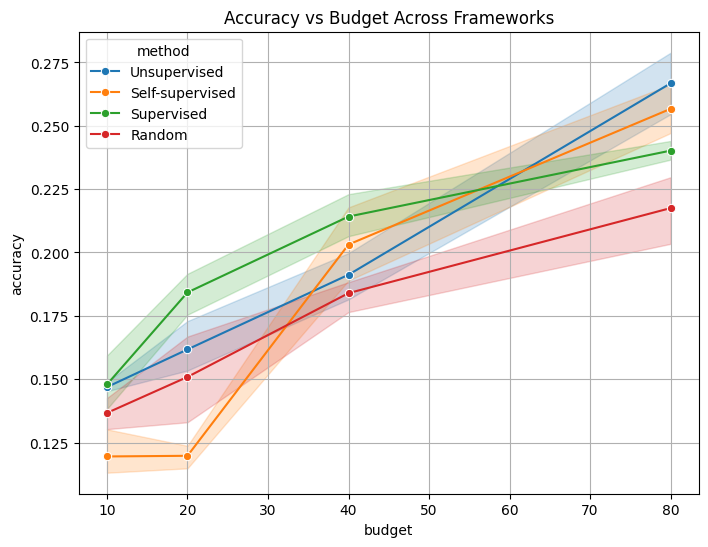

In [7]:
plt.figure(figsize=(8,6))
sns.lineplot(data=df, x="budget", y="accuracy", hue="method", marker="o")
plt.title("Accuracy vs Budget Across Frameworks")
plt.grid(True)
plt.show()


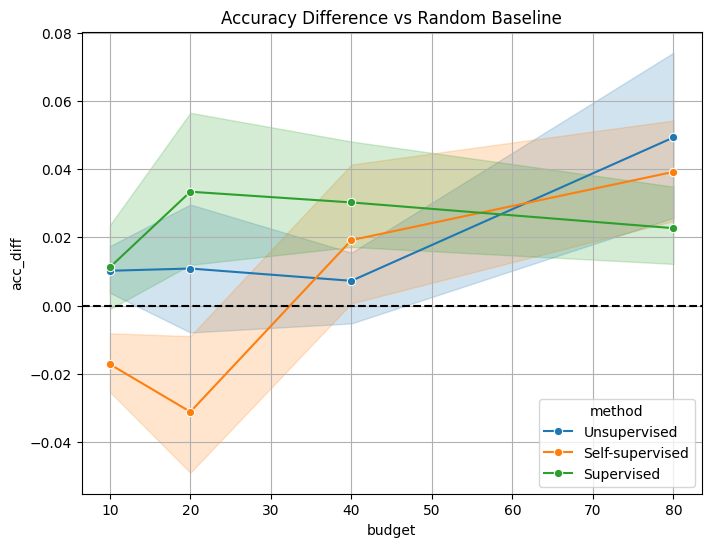

In [8]:
df_random = df[df["method"] == "Random"].set_index(["budget", "seed"])

df["acc_diff"] = df.apply(
    lambda row: row["accuracy"] - df_random.loc[(row["budget"], row["seed"]), "accuracy"],
    axis=1
)

plt.figure(figsize=(8,6))
sns.lineplot(data=df[df["method"] != "Random"],
             x="budget", y="acc_diff", hue="method", marker="o")
plt.axhline(0, color="black", linestyle="--")
plt.title("Accuracy Difference vs Random Baseline")
plt.grid(True)
plt.show()


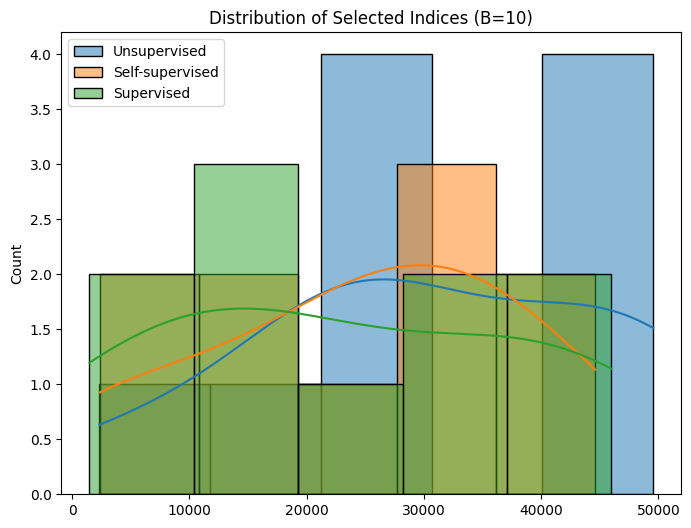

In [11]:
plt.figure(figsize=(8,6))
sns.histplot(typiclust_unsup[10], label="Unsupervised", kde=True)
sns.histplot(typiclust_ssl[10], label="Self-supervised", kde=True)
sns.histplot(typiclust_sup[10], label="Supervised", kde=True)
plt.legend()
plt.title("Distribution of Selected Indices (B=10)")
plt.show()
